# Inferência
Recebe o caminho de uma imagem, devolve a máscara colorida e a contagem de instâncias. Roda sem retreinar.

In [7]:
import sys
import os
import glob
sys.path.append(os.path.abspath('..')) 
%load_ext autoreload
%autoreload 2
from src import *

import torch
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from src.models import UNetTernary
from src.evaluating import decode_watershed

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNetTernary().to(DEVICE)
model.load_state_dict(torch.load('../models/best_model_ternary.pt', map_location=DEVICE))
model.eval()

def inferir(hash_imagem):
    # Caminho da imagem
    caminho = f"../data/stage1_train/{hash_imagem}/images/{hash_imagem}.png"
    img = cv.imread(caminho, cv.IMREAD_COLOR)
    
    # Trava de segurança: se a imagem não existir, avisa em vez de quebrar
    if img is None:
        print(f"Erro: Imagem não encontrada no caminho:\n{caminho}")
        return None, 0, 0
        
    # Descobre a contagem real (Ground Truth) contando as máscaras da pasta masks
    pasta_masks = f"../data/stage1_train/{hash_imagem}/masks/"
    masks_gt_paths = glob.glob(os.path.join(pasta_masks, "*.png"))
    contagem_real = len(masks_gt_paths)
        
    img_rs = cv.resize(cv.cvtColor(img, cv.COLOR_BGR2RGB), (256, 256))
    img_t = torch.from_numpy(img_rs / 255.0).permute(2,0,1).float().unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        cls, dist = model(img_t)
        p = torch.nn.functional.softmax(cls, dim=1)[0].cpu().numpy()
        d = dist.squeeze(1)[0].cpu().numpy()
        
    masks = decode_watershed(p, d, 0.3, 0.5, 2)
    mask_color = np.zeros_like(img_rs)
    for m in masks: 
        mask_color[m > 0] = np.random.randint(50, 255, 3)
    
    contagem_pred = len(masks)
    
    fig, ax = plt.subplots(1, 2, figsize=(10,5))
    ax[0].imshow(img_rs)
    ax[0].axis('off')
    ax[0].set_title('Imagem Original')
    
    ax[1].imshow(mask_color)
    ax[1].axis('off')
    ax[1].set_title(f'Predito: {contagem_pred} | Real (GT): {contagem_real}')
    
    plt.show()
    return mask_color, contagem_pred, contagem_real

# Exemplo de chamada:
# mask, count_pred, count_real = inferir('0a7d30b252359a10fd298b638b90cb9ada3acced4e0c0e5a3692013f432e6e25')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


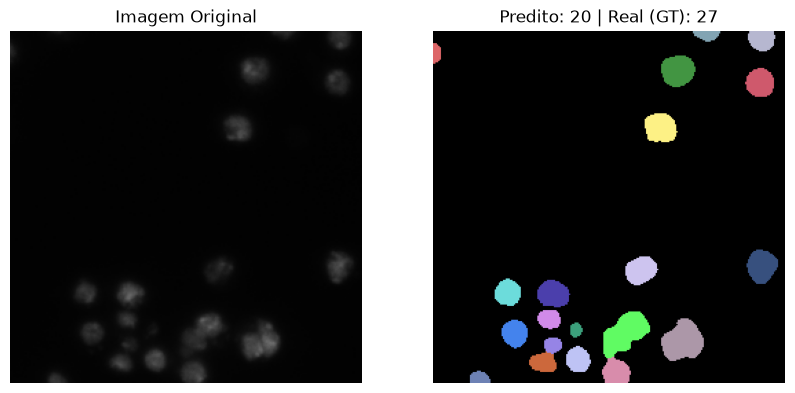

In [8]:
hash = '00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552'
mask, count_pred, count_real = inferir(hash)

Total de imagens encontradas: 670

Processando: ../data/stage1_train\00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552\images\00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552.png


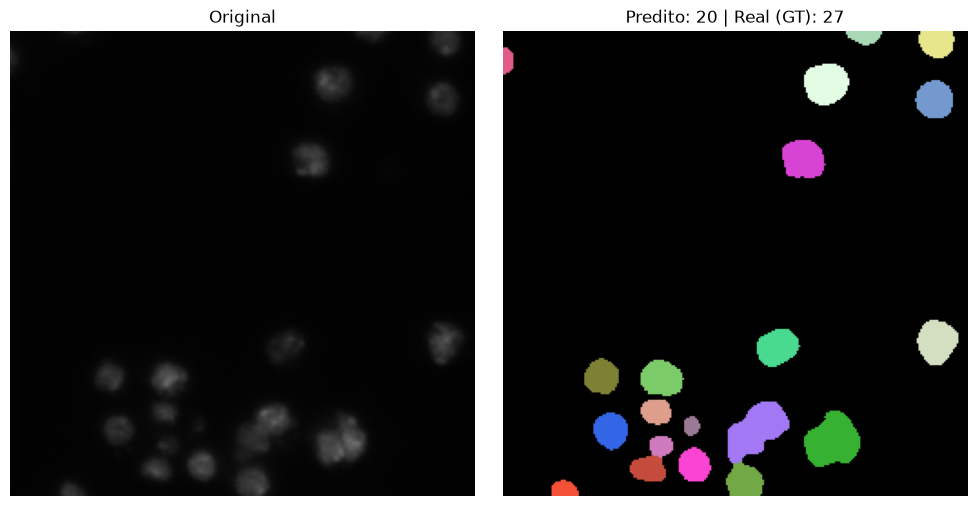

Processando: ../data/stage1_train\003cee89357d9fe13516167fd67b609a164651b21934585648c740d2c3d86dc1\images\003cee89357d9fe13516167fd67b609a164651b21934585648c740d2c3d86dc1.png


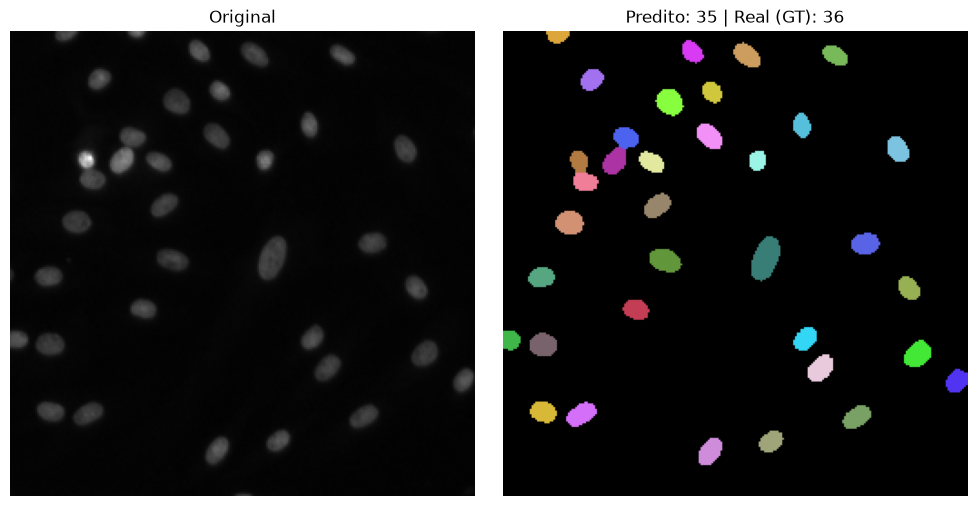

Processando: ../data/stage1_train\00ae65c1c6631ae6f2be1a449902976e6eb8483bf6b0740d00530220832c6d3e\images\00ae65c1c6631ae6f2be1a449902976e6eb8483bf6b0740d00530220832c6d3e.png


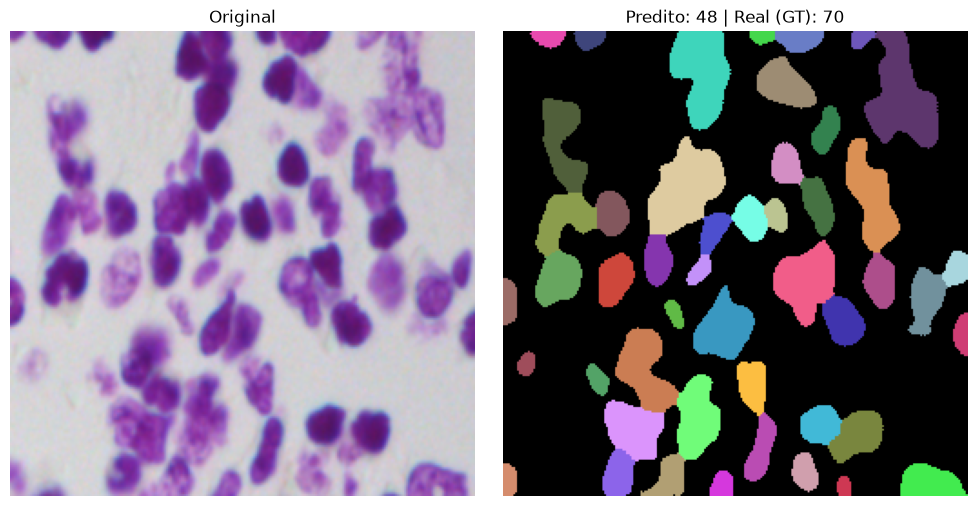

Processando: ../data/stage1_train\0121d6759c5adb290c8e828fc882f37dfaf3663ec885c663859948c154a443ed\images\0121d6759c5adb290c8e828fc882f37dfaf3663ec885c663859948c154a443ed.png


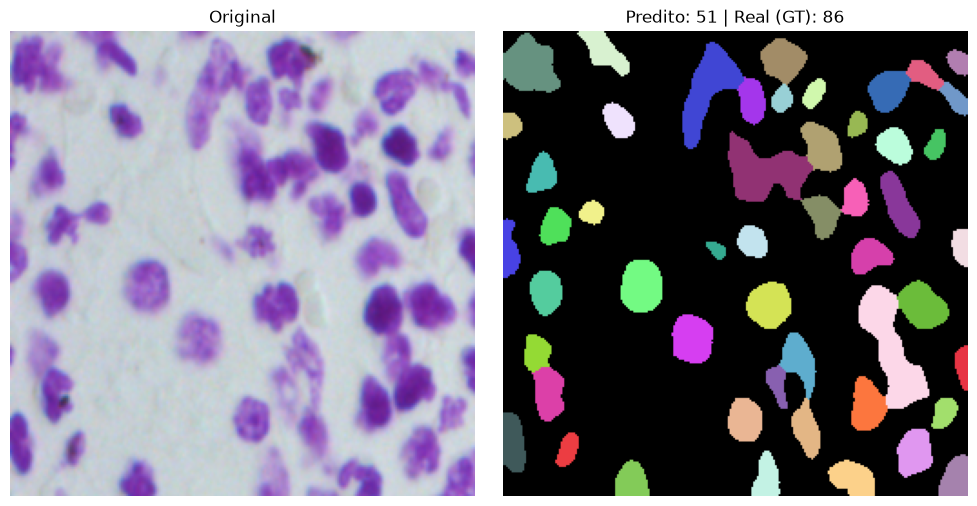

Processando: ../data/stage1_train\01d44a26f6680c42ba94c9bc6339228579a95d0e2695b149b7cc0c9592b21baf\images\01d44a26f6680c42ba94c9bc6339228579a95d0e2695b149b7cc0c9592b21baf.png


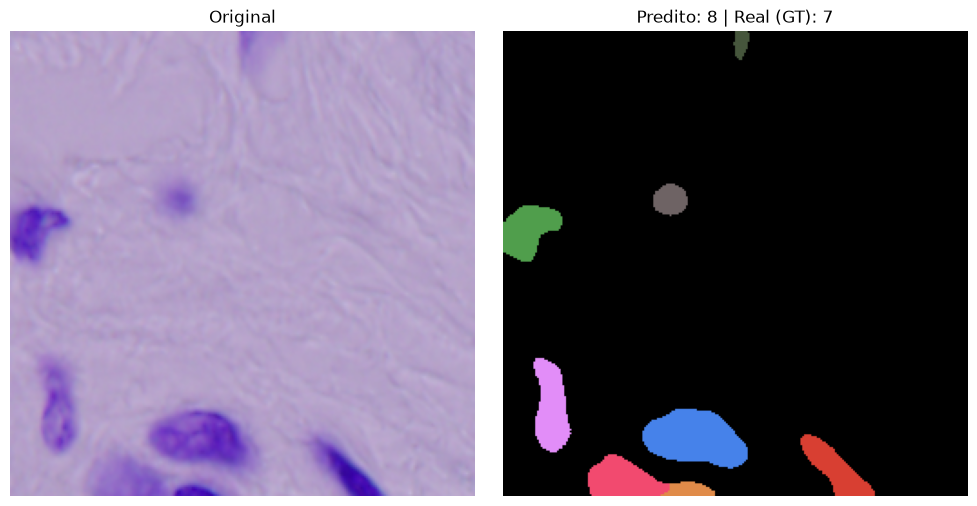

Processando: ../data/stage1_train\0280fa8f60f6bcae0f97d93c28f60be194f9309ff610dc5845e60455b0f87c21\images\0280fa8f60f6bcae0f97d93c28f60be194f9309ff610dc5845e60455b0f87c21.png


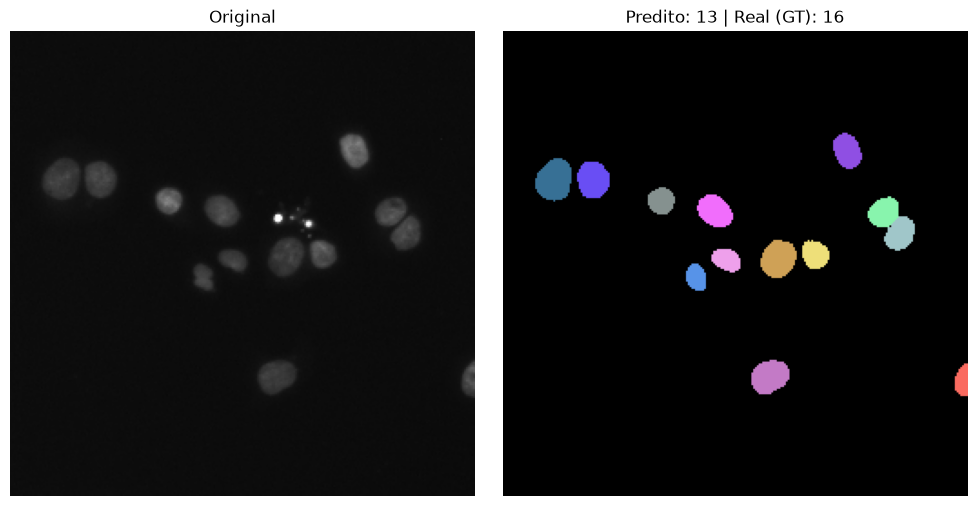

Processando: ../data/stage1_train\0287e7ee5b007c91ae2bd7628d09735e70496bc6127ecb7f3dd043e04ce37426\images\0287e7ee5b007c91ae2bd7628d09735e70496bc6127ecb7f3dd043e04ce37426.png


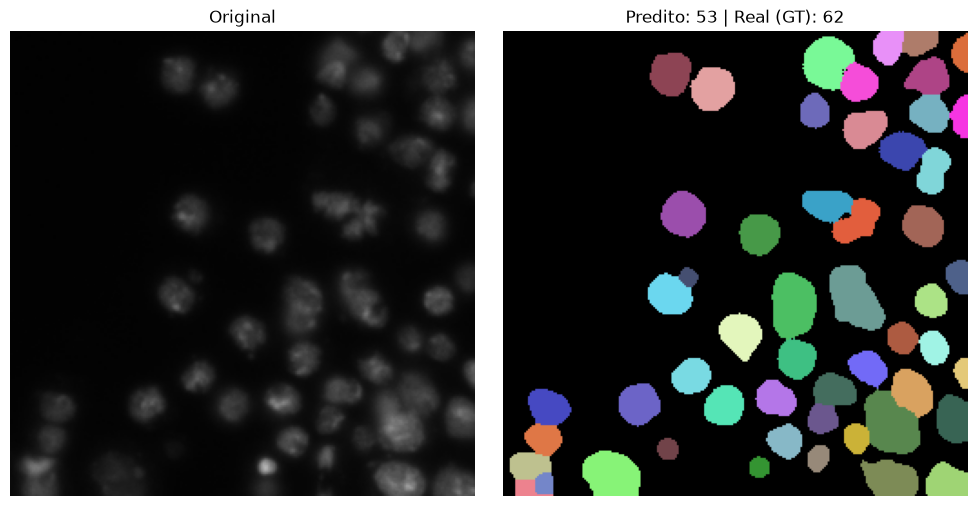

Processando: ../data/stage1_train\02903040e19ddf92f452907644ad3822918f54af41dd85e5a3fe3e1b6d6f9339\images\02903040e19ddf92f452907644ad3822918f54af41dd85e5a3fe3e1b6d6f9339.png


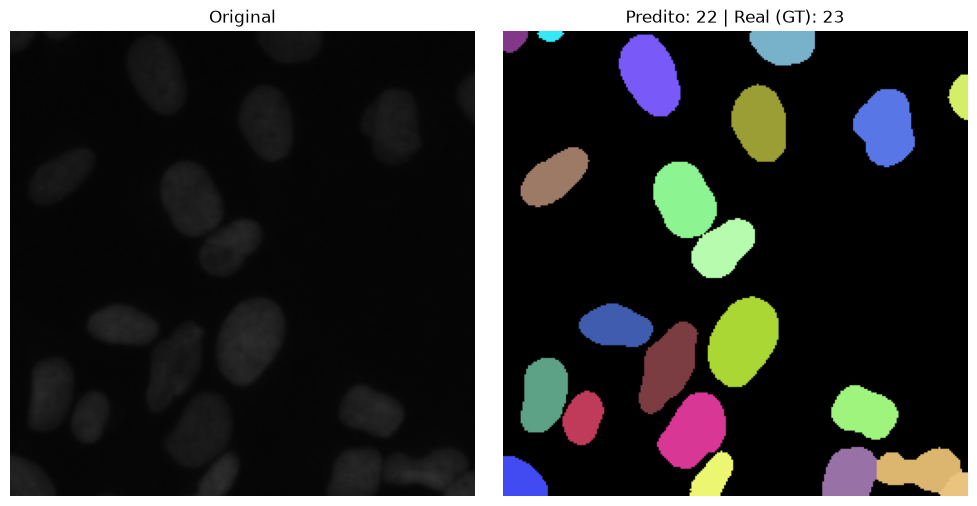

Processando: ../data/stage1_train\03398329ced0c23b9ac3fac84dd53a87d9ffe4d9d10f1b5fe8df8fac12380776\images\03398329ced0c23b9ac3fac84dd53a87d9ffe4d9d10f1b5fe8df8fac12380776.png


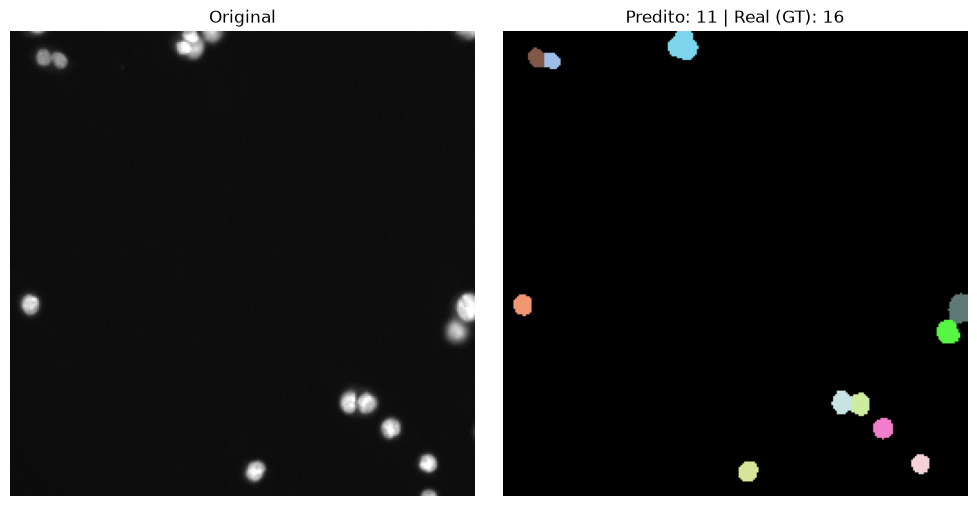

Processando: ../data/stage1_train\03b9306f44e9b8951461623dcbd615550cdcf36ea93b203f2c8fa58ed1dffcbe\images\03b9306f44e9b8951461623dcbd615550cdcf36ea93b203f2c8fa58ed1dffcbe.png


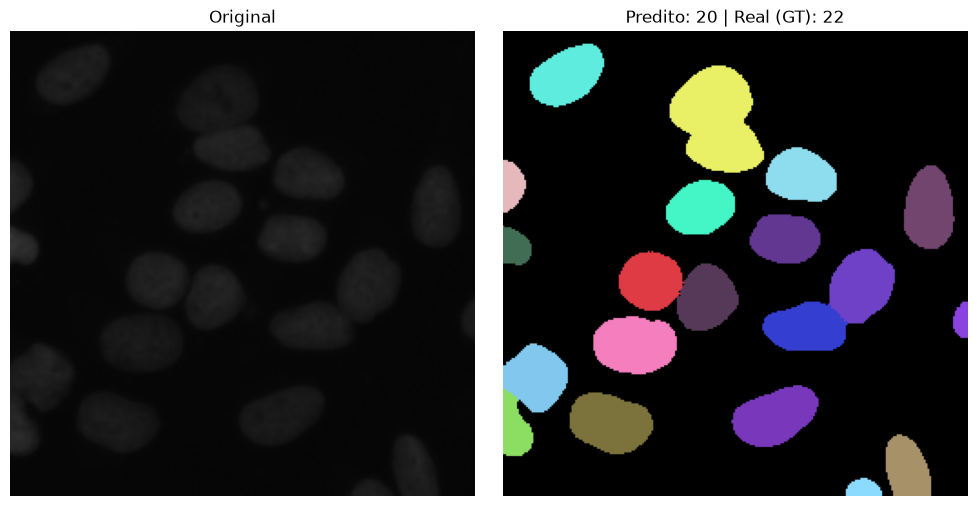

Processando: ../data/stage1_train\03f583ec5018739f4abb9b3b4a580ac43bd933c4337ad8877aa18b1dfb59fc9a\images\03f583ec5018739f4abb9b3b4a580ac43bd933c4337ad8877aa18b1dfb59fc9a.png


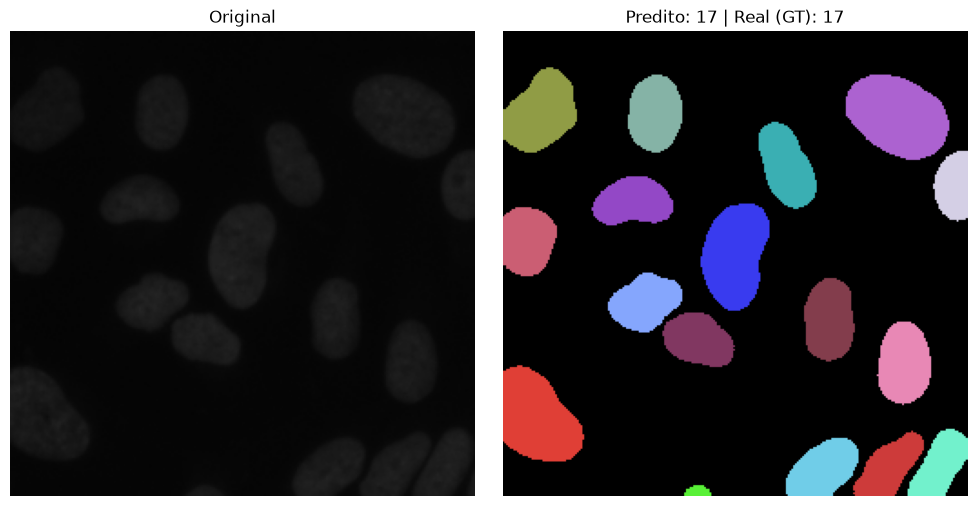

Processando: ../data/stage1_train\0402a81e75262469925ea893b6706183832e85324f7b1e08e634129f5d522cdd\images\0402a81e75262469925ea893b6706183832e85324f7b1e08e634129f5d522cdd.png


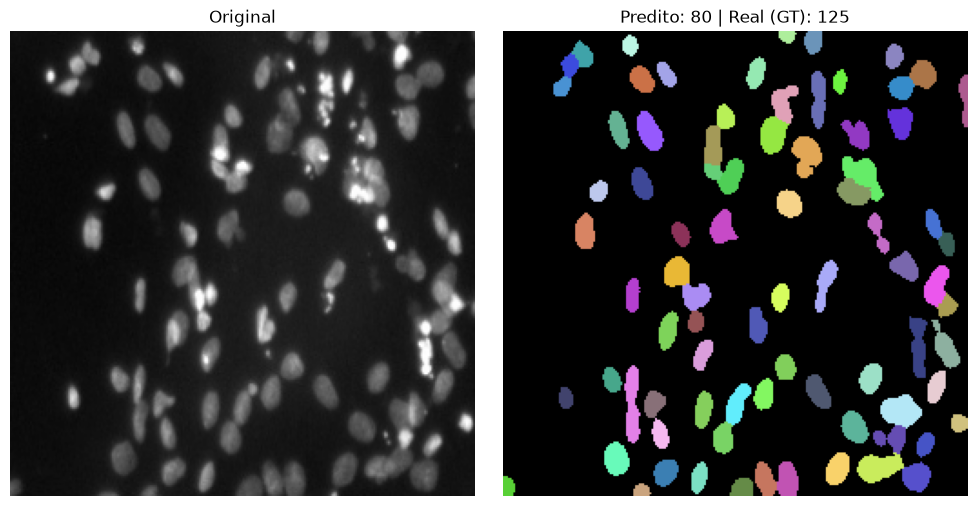

Processando: ../data/stage1_train\04acab7636c4cf61d288a5962f15fa456b7bde31a021e5deedfbf51288e4001e\images\04acab7636c4cf61d288a5962f15fa456b7bde31a021e5deedfbf51288e4001e.png


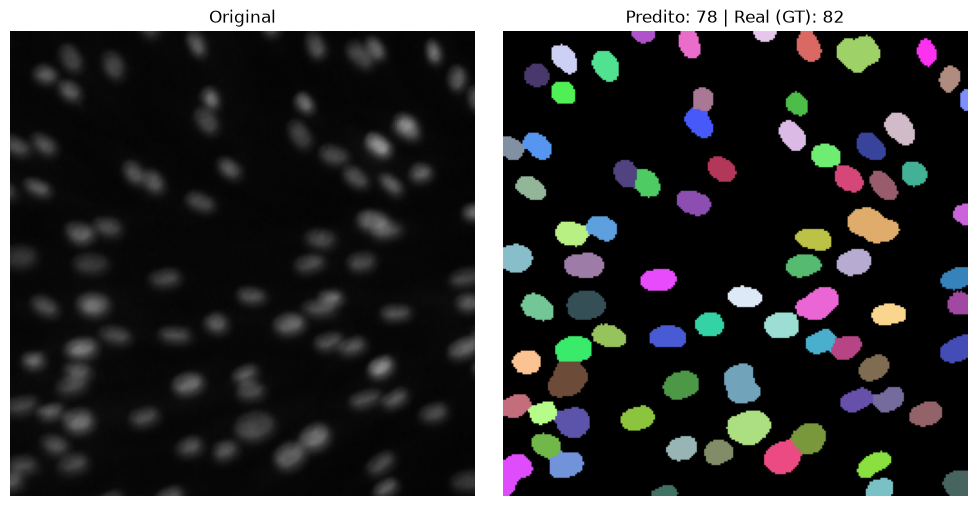

Processando: ../data/stage1_train\05040e2e959c3f5632558fc9683fec88f0010026c555b499066346f67fdd0e13\images\05040e2e959c3f5632558fc9683fec88f0010026c555b499066346f67fdd0e13.png


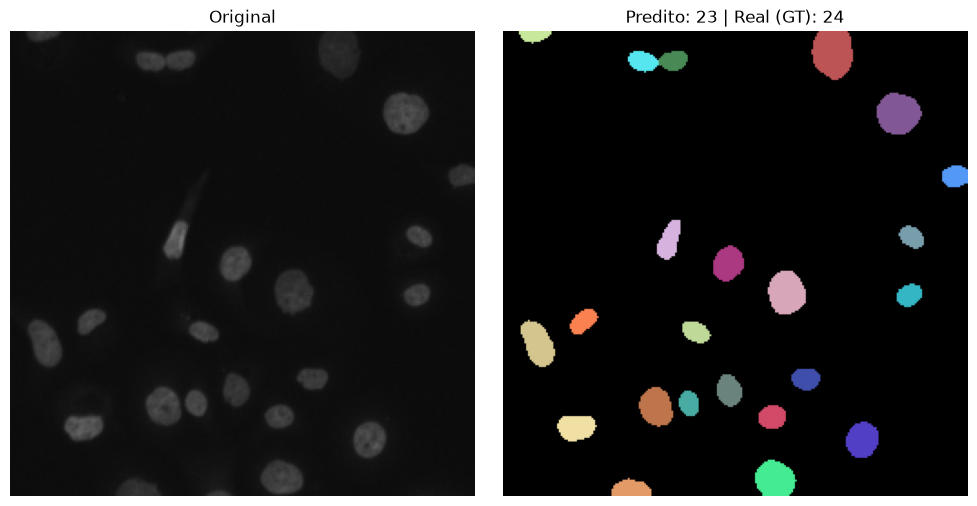

Processando: ../data/stage1_train\0532c64c2fd0c4d3188cc751cdfd566b1cfba3d269358717295bab1504c7c275\images\0532c64c2fd0c4d3188cc751cdfd566b1cfba3d269358717295bab1504c7c275.png


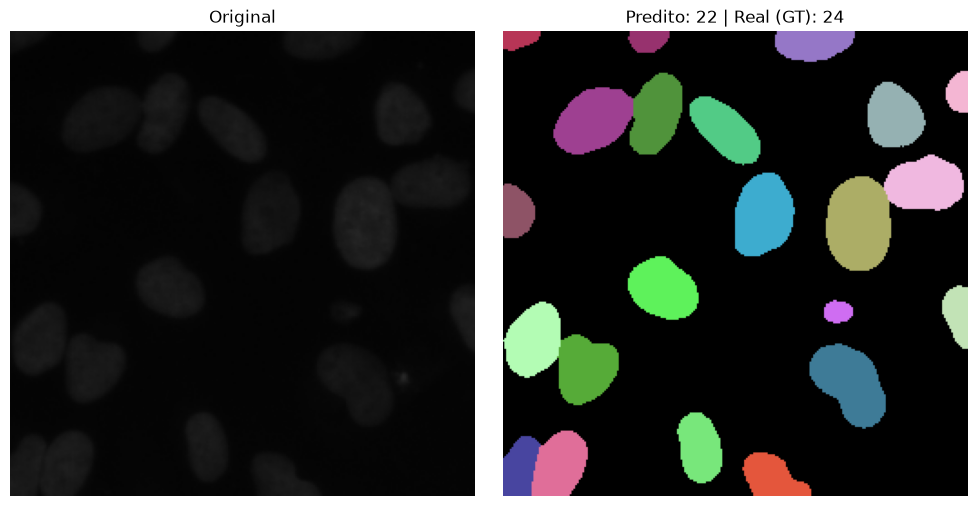

Processando: ../data/stage1_train\05a8f65ebd0b30d3b210f30b4d640c847c2e710d0d135e0aeeaccbe1988e3b6e\images\05a8f65ebd0b30d3b210f30b4d640c847c2e710d0d135e0aeeaccbe1988e3b6e.png


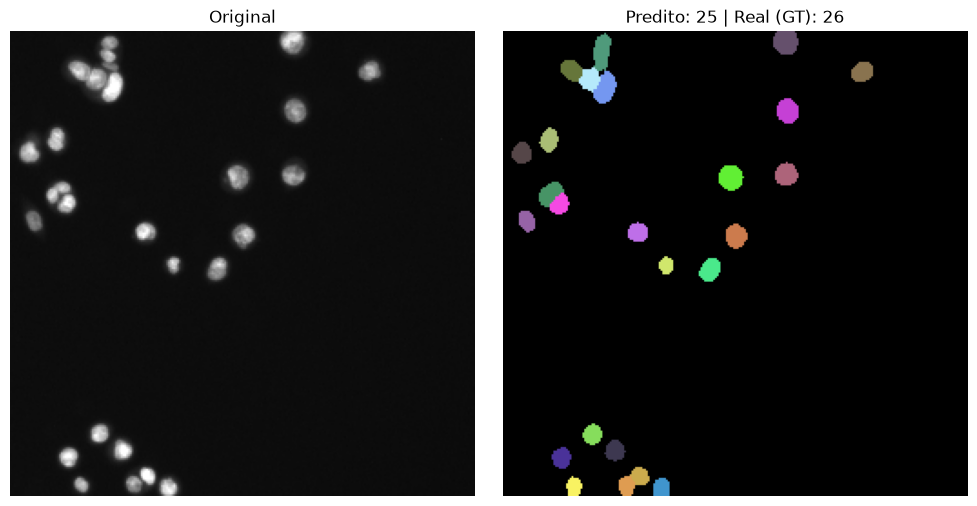

Processando: ../data/stage1_train\06350c7cc618be442c15706db7a68e91f313758d224de4608f9b960106d4f9ca\images\06350c7cc618be442c15706db7a68e91f313758d224de4608f9b960106d4f9ca.png


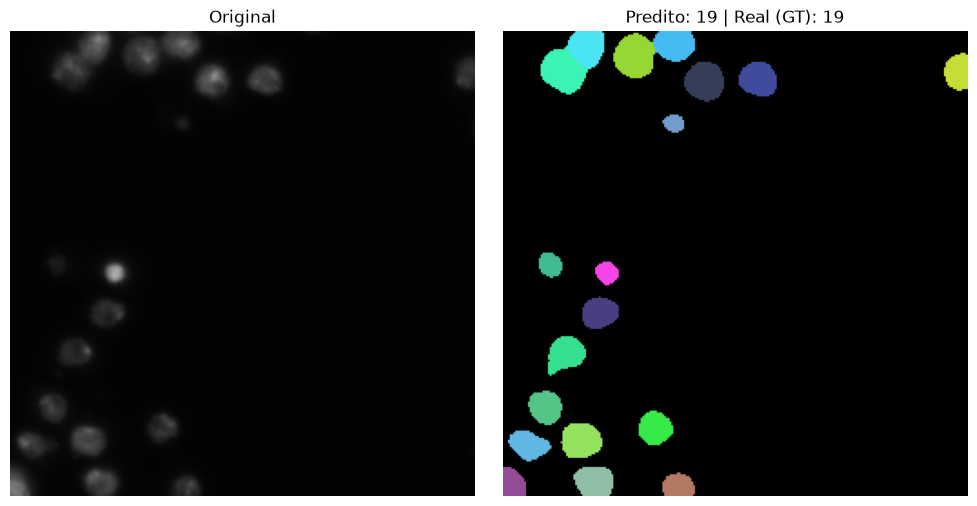

Processando: ../data/stage1_train\06c779330d6d3447be21df2b9f05d1088f5b3b50dc48724fc130b1fd2896a68c\images\06c779330d6d3447be21df2b9f05d1088f5b3b50dc48724fc130b1fd2896a68c.png


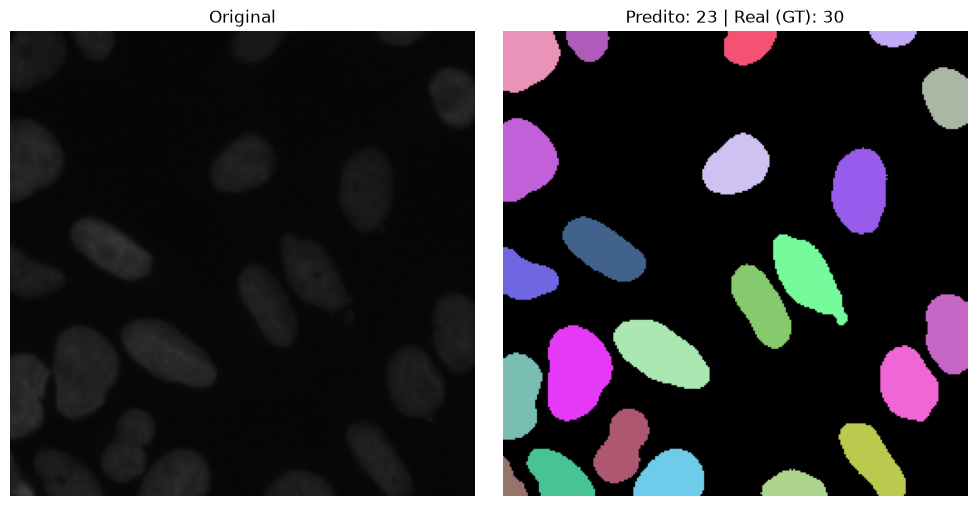

Processando: ../data/stage1_train\072ff14c1d3245bf49ad6f1d4c71cdb18f1cb78a8e06fd2f53767e28f727cb81\images\072ff14c1d3245bf49ad6f1d4c71cdb18f1cb78a8e06fd2f53767e28f727cb81.png


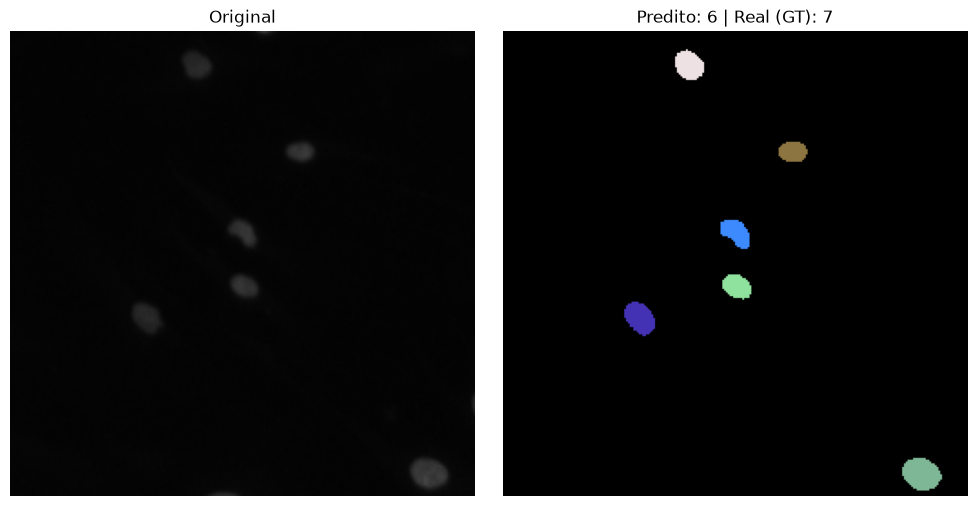

Processando: ../data/stage1_train\07761fa39f60dc37022dbbe8d8694595fd5b77ceb2af2a2724768c8e524d6770\images\07761fa39f60dc37022dbbe8d8694595fd5b77ceb2af2a2724768c8e524d6770.png


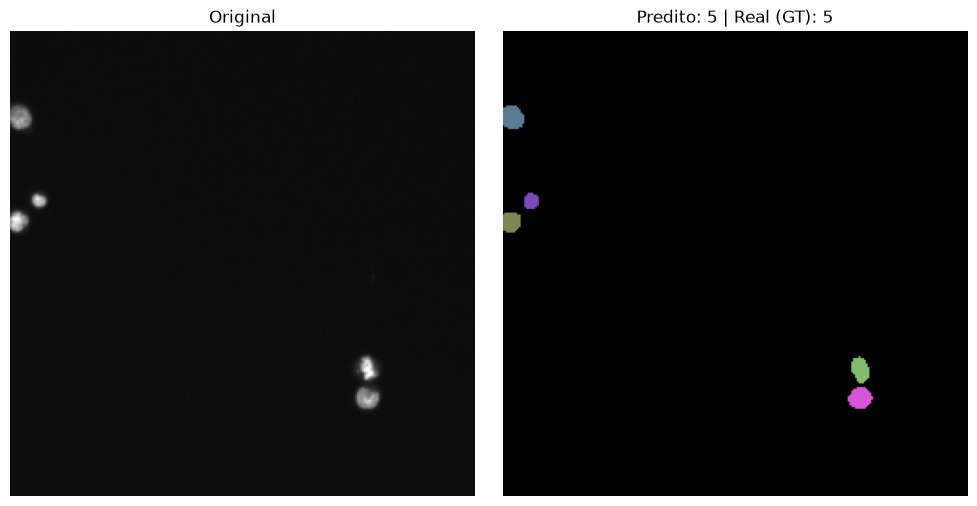

Processando: ../data/stage1_train\077f026f4ab0f0bcc0856644d99cbf639e443ec4f067d7b708bc6cecac609424\images\077f026f4ab0f0bcc0856644d99cbf639e443ec4f067d7b708bc6cecac609424.png


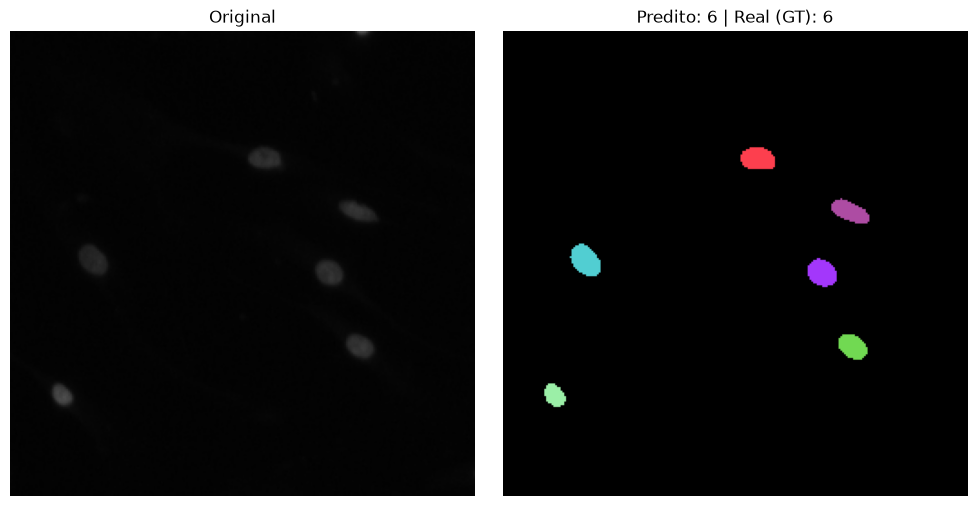

Processando: ../data/stage1_train\07fb37aafa6626608af90c1e18f6a743f29b6b233d2e427dcd1102df6a916cf5\images\07fb37aafa6626608af90c1e18f6a743f29b6b233d2e427dcd1102df6a916cf5.png


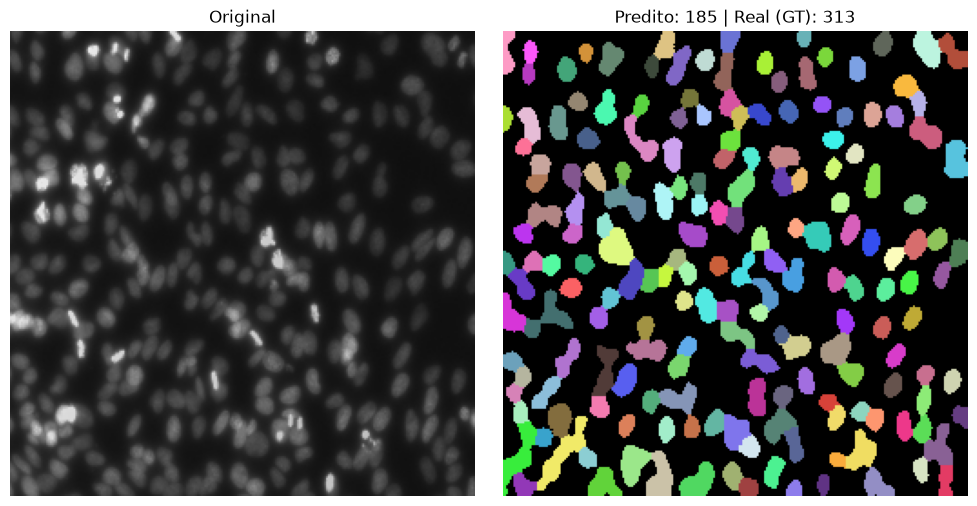

Processando: ../data/stage1_train\08151b19806eebd58e5acec7e138dbfbb1761f41a1ab9620466584ecc7d5fada\images\08151b19806eebd58e5acec7e138dbfbb1761f41a1ab9620466584ecc7d5fada.png


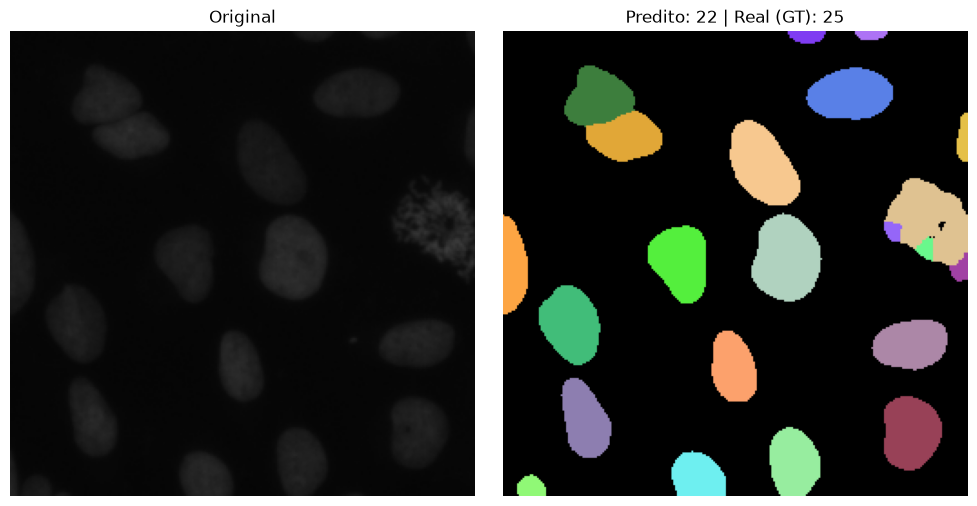

Processando: ../data/stage1_train\08275a5b1c2dfcd739e8c4888a5ee2d29f83eccfa75185404ced1dc0866ea992\images\08275a5b1c2dfcd739e8c4888a5ee2d29f83eccfa75185404ced1dc0866ea992.png


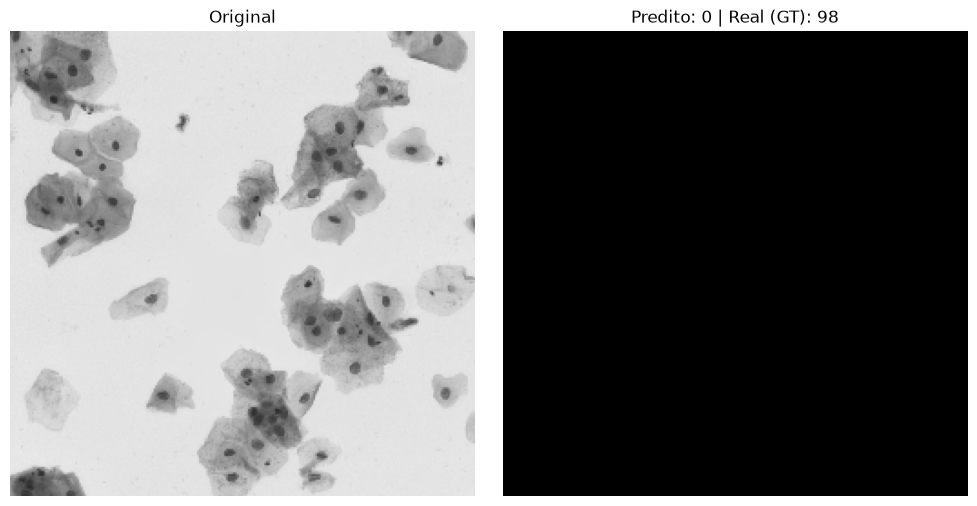

Processando: ../data/stage1_train\08ae2741df2f5ac815c0f272a8c532b5167ee853be9b939b9b8b7fa93560868a\images\08ae2741df2f5ac815c0f272a8c532b5167ee853be9b939b9b8b7fa93560868a.png


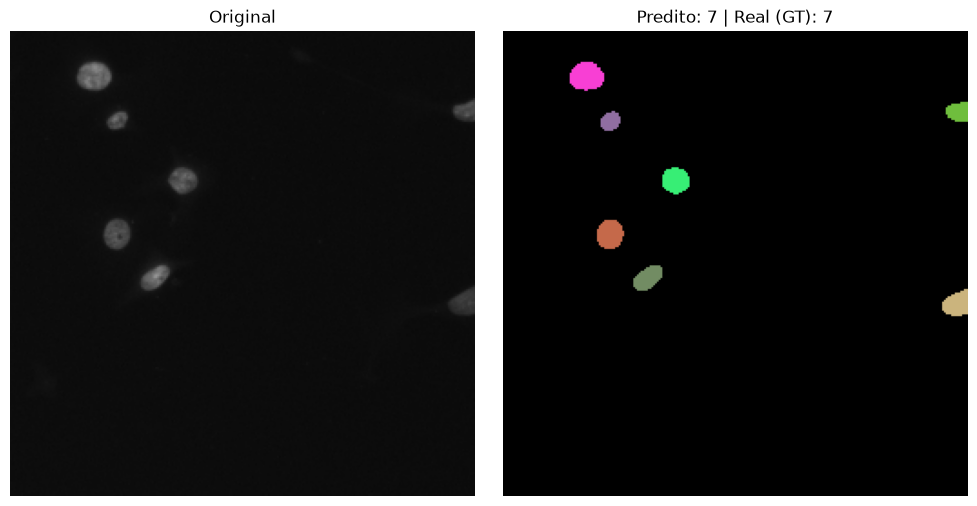

Processando: ../data/stage1_train\091944f1d2611c916b98c020bd066667e33f4639159b2a92407fe5a40788856d\images\091944f1d2611c916b98c020bd066667e33f4639159b2a92407fe5a40788856d.png


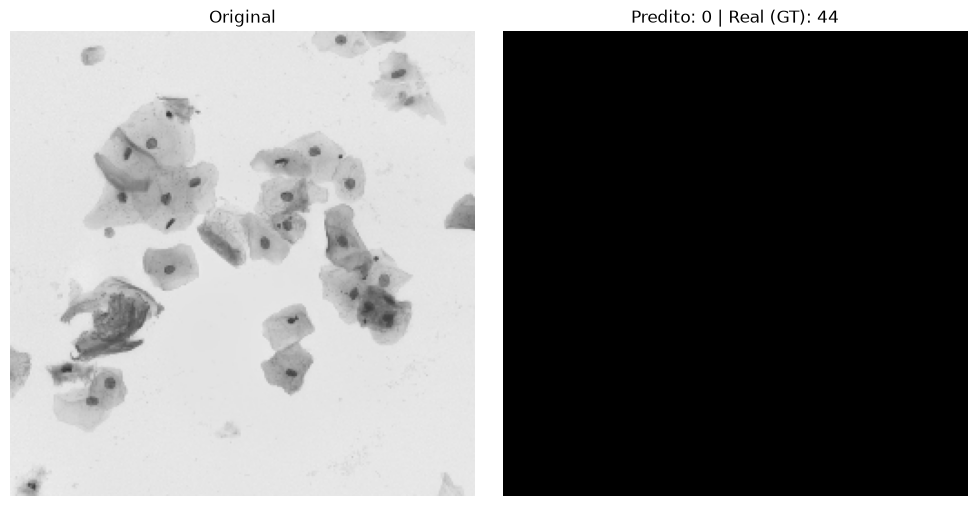

Processando: ../data/stage1_train\094afe36759e7daffe12188ab5987581d405b06720f1d5acf3f2614f404df380\images\094afe36759e7daffe12188ab5987581d405b06720f1d5acf3f2614f404df380.png


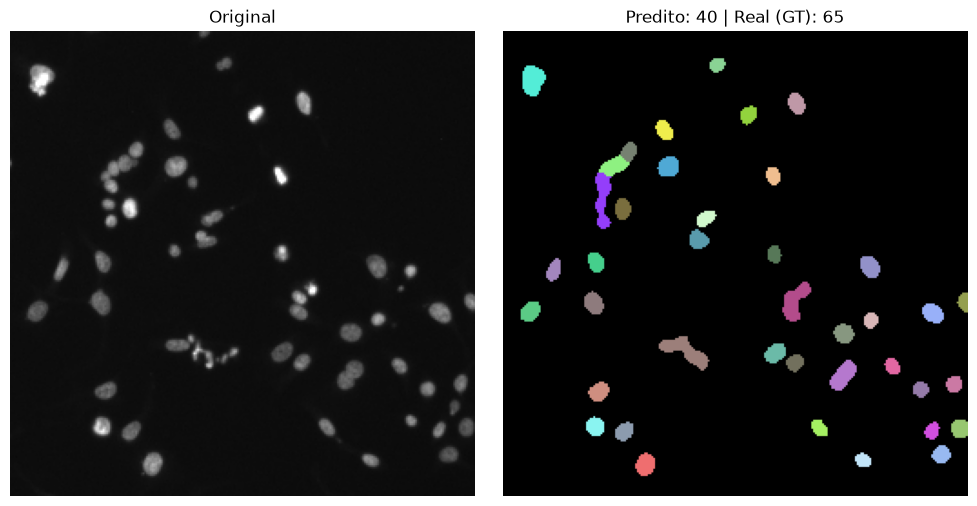

Processando: ../data/stage1_train\0a7d30b252359a10fd298b638b90cb9ada3acced4e0c0e5a3692013f432ee4e9\images\0a7d30b252359a10fd298b638b90cb9ada3acced4e0c0e5a3692013f432ee4e9.png


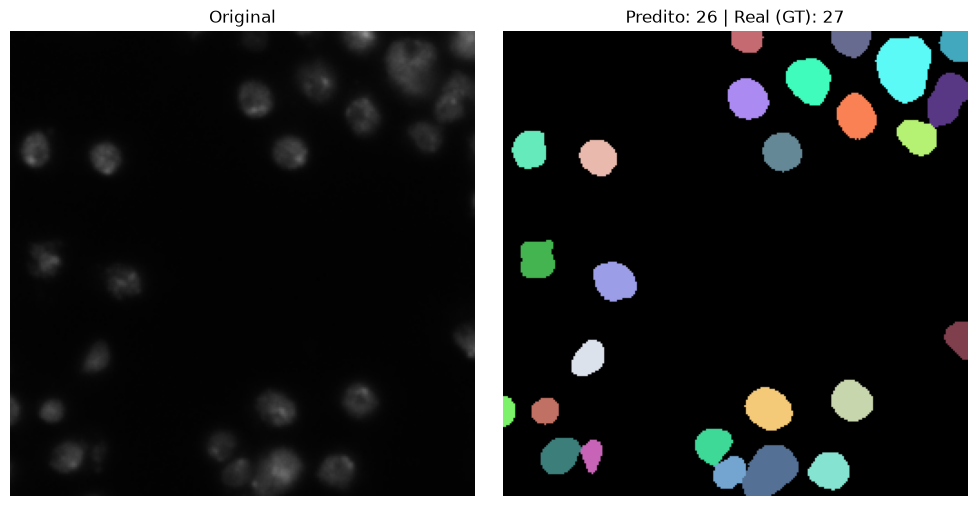

Processando: ../data/stage1_train\0acd2c223d300ea55d0546797713851e818e5c697d073b7f4091b96ce0f3d2fe\images\0acd2c223d300ea55d0546797713851e818e5c697d073b7f4091b96ce0f3d2fe.png


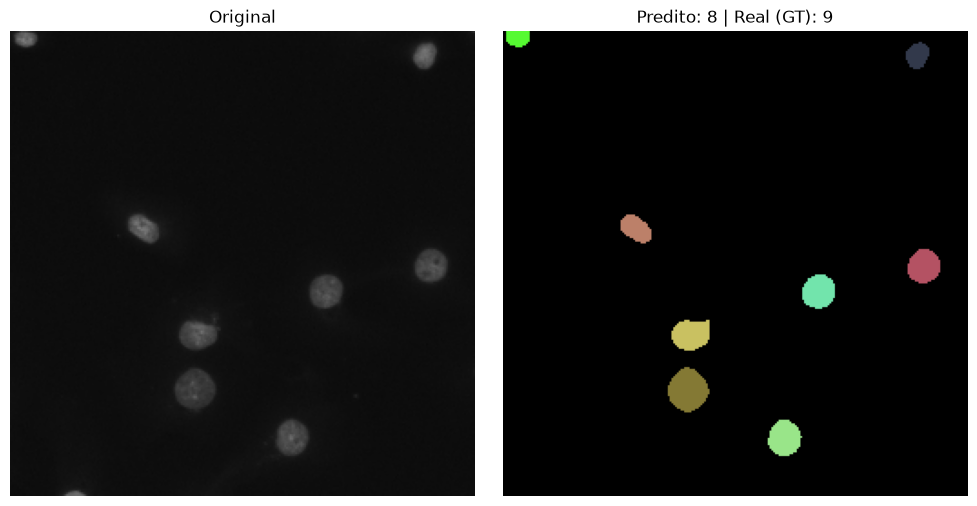

Processando: ../data/stage1_train\0b0d577159f0d6c266f360f7b8dfde46e16fa665138bf577ec3c6f9c70c0cd1e\images\0b0d577159f0d6c266f360f7b8dfde46e16fa665138bf577ec3c6f9c70c0cd1e.png


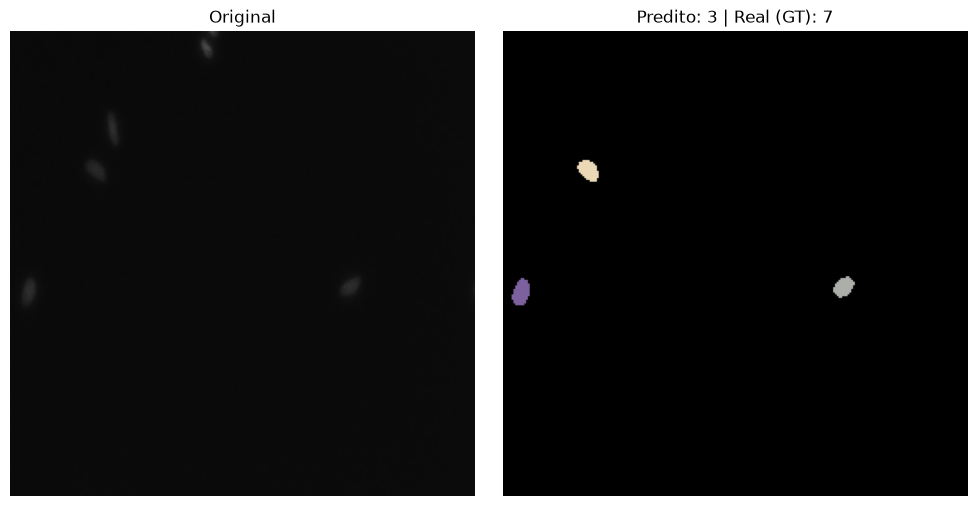

Processando: ../data/stage1_train\0b2e702f90aee4fff2bc6e4326308d50cf04701082e718d4f831c8959fbcda93\images\0b2e702f90aee4fff2bc6e4326308d50cf04701082e718d4f831c8959fbcda93.png


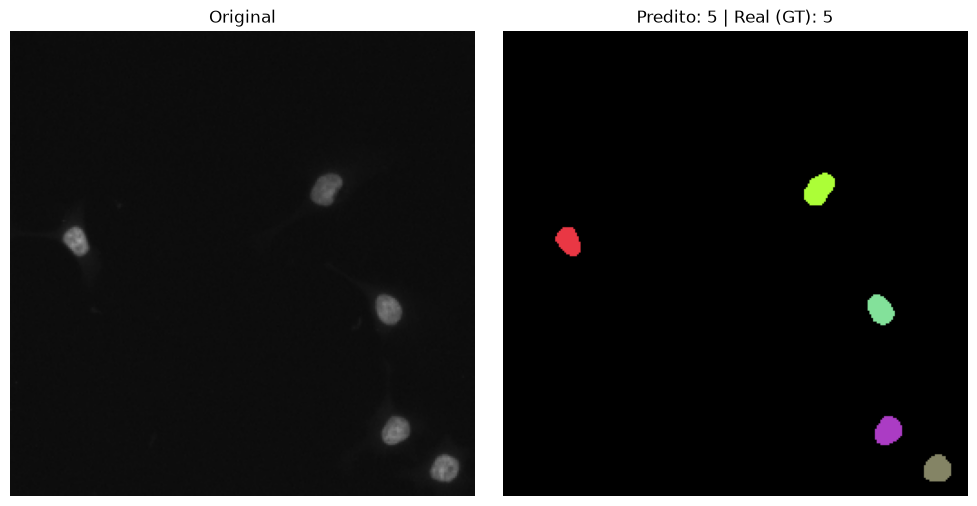

Processando: ../data/stage1_train\0bda515e370294ed94efd36bd53782288acacb040c171df2ed97fd691fc9d8fe\images\0bda515e370294ed94efd36bd53782288acacb040c171df2ed97fd691fc9d8fe.png


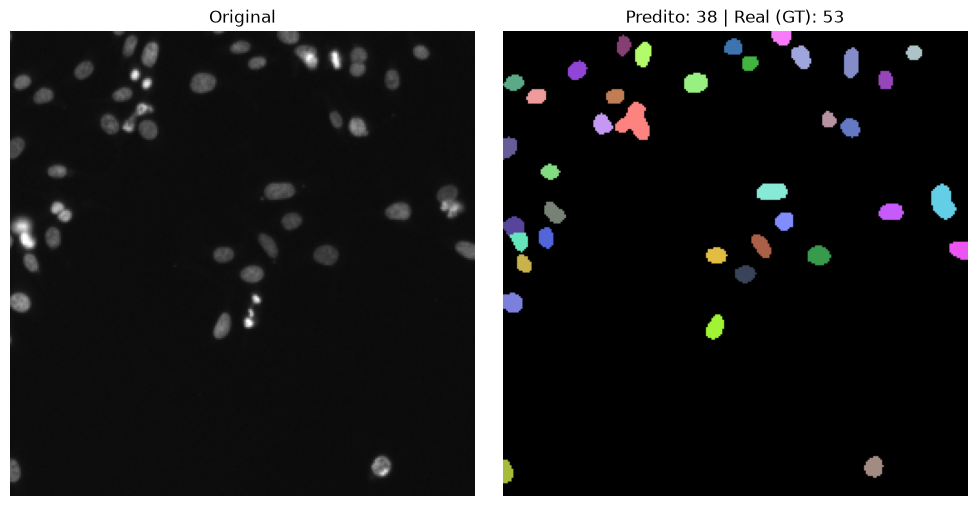

Processando: ../data/stage1_train\0bf33d3db4282d918ec3da7112d0bf0427d4eafe74b3ee0bb419770eefe8d7d6\images\0bf33d3db4282d918ec3da7112d0bf0427d4eafe74b3ee0bb419770eefe8d7d6.png


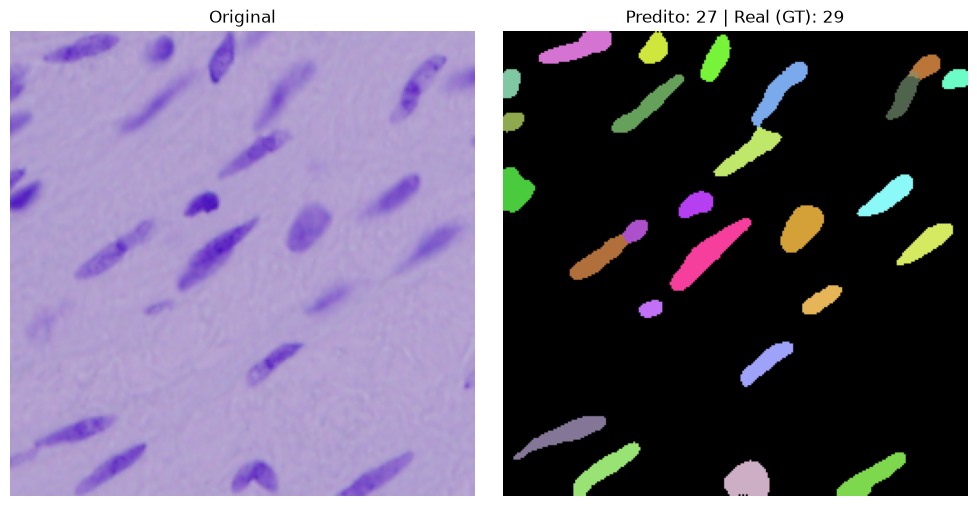

Processando: ../data/stage1_train\0bf4b144167694b6846d584cf52c458f34f28fcae75328a2a096c8214e01c0d0\images\0bf4b144167694b6846d584cf52c458f34f28fcae75328a2a096c8214e01c0d0.png


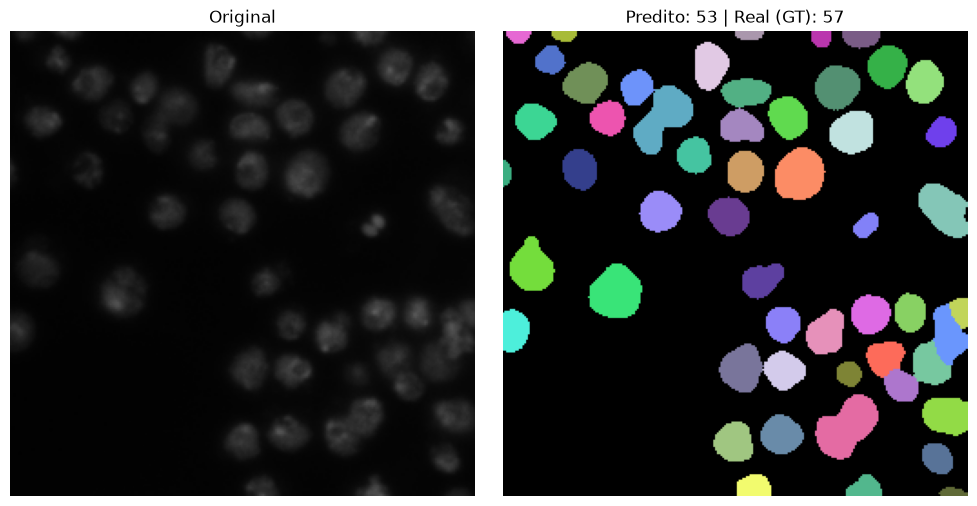

Processando: ../data/stage1_train\0c2550a23b8a0f29a7575de8c61690d3c31bc897dd5ba66caec201d201a278c2\images\0c2550a23b8a0f29a7575de8c61690d3c31bc897dd5ba66caec201d201a278c2.png


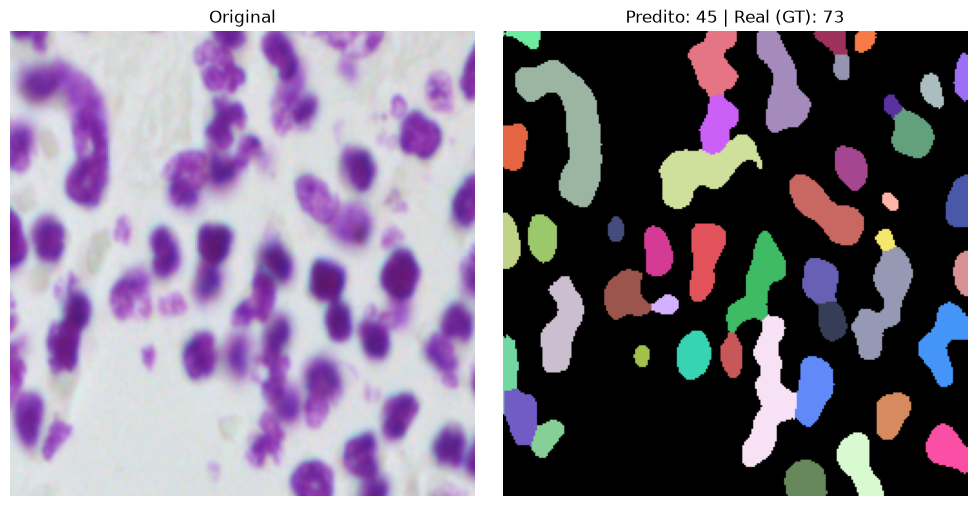

Processando: ../data/stage1_train\0c6507d493bf79b2ba248c5cca3d14df8b67328b89efa5f4a32f97a06a88c92c\images\0c6507d493bf79b2ba248c5cca3d14df8b67328b89efa5f4a32f97a06a88c92c.png


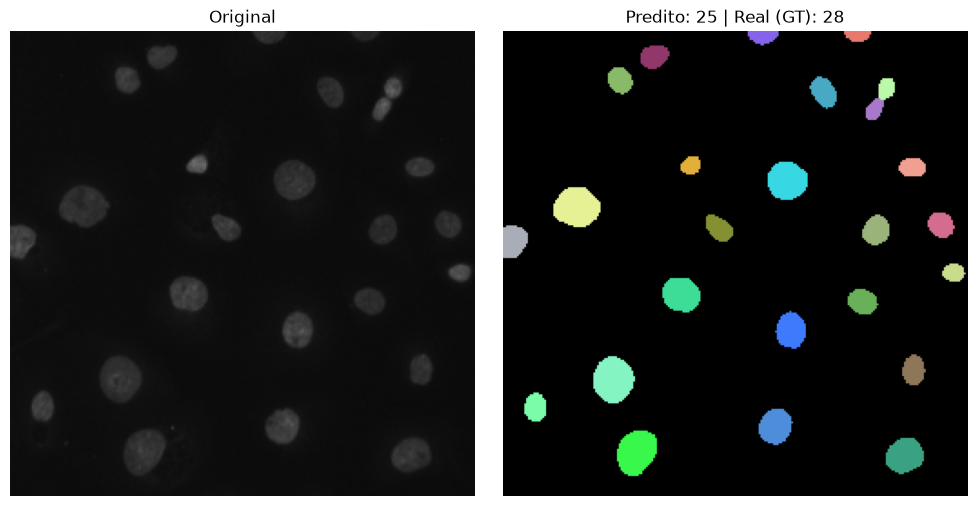

Processando: ../data/stage1_train\0d2bf916cc8de90d02f4cd4c23ea79b227dbc45d845b4124ffea380c92d34c8c\images\0d2bf916cc8de90d02f4cd4c23ea79b227dbc45d845b4124ffea380c92d34c8c.png


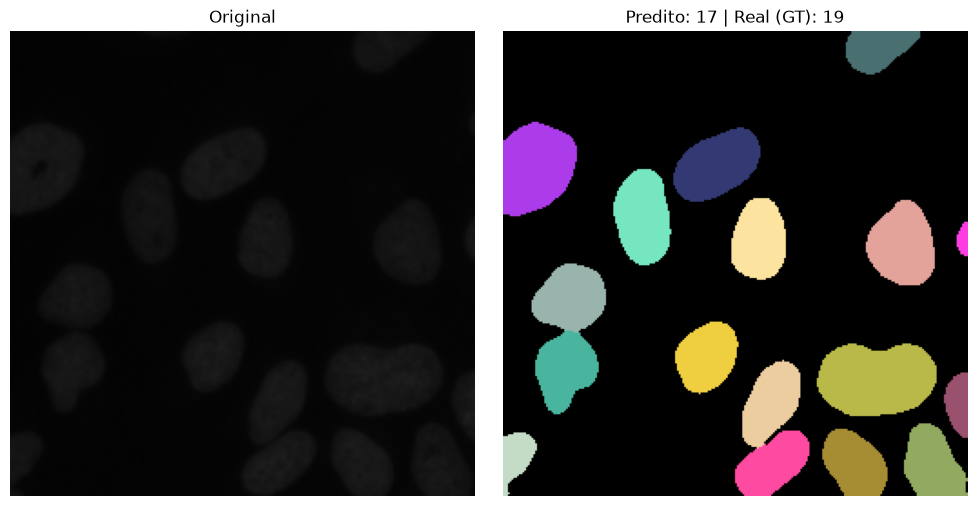

Processando: ../data/stage1_train\0d3640c1f1b80f24e94cc9a5f3e1d9e8db7bf6af7d4aba920265f46cadc25e37\images\0d3640c1f1b80f24e94cc9a5f3e1d9e8db7bf6af7d4aba920265f46cadc25e37.png


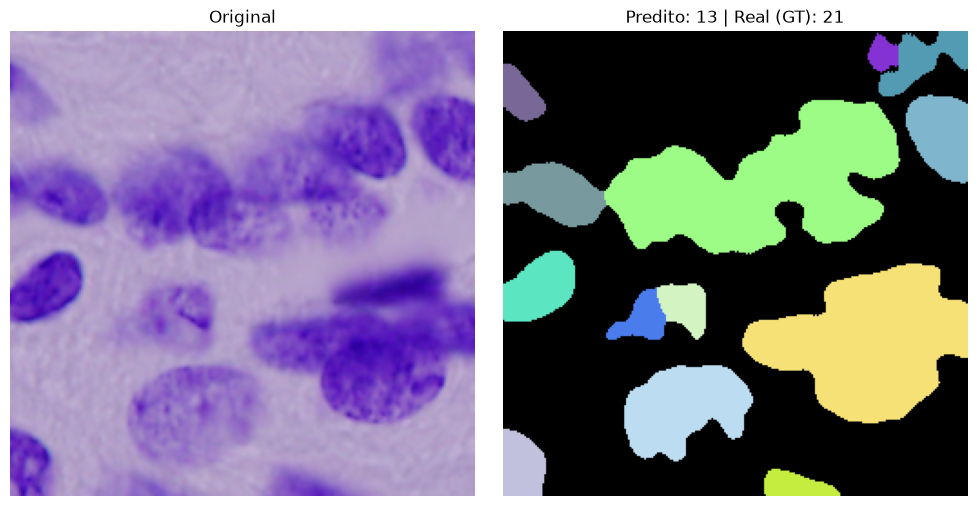

Processando: ../data/stage1_train\0ddd8deaf1696db68b00c600601c6a74a0502caaf274222c8367bdc31458ae7e\images\0ddd8deaf1696db68b00c600601c6a74a0502caaf274222c8367bdc31458ae7e.png


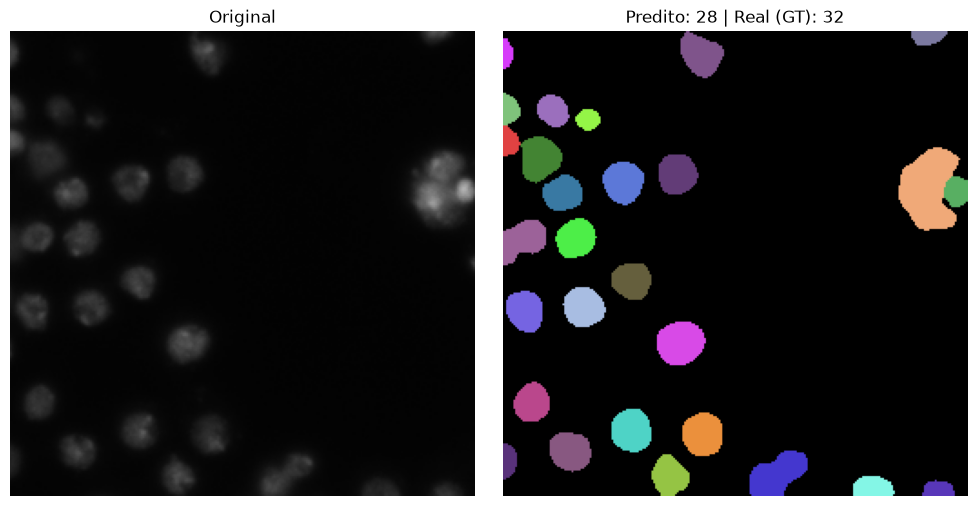

Processando: ../data/stage1_train\0e21d7b3eea8cdbbed60d51d72f4f8c1974c5d76a8a3893a7d5835c85284132e\images\0e21d7b3eea8cdbbed60d51d72f4f8c1974c5d76a8a3893a7d5835c85284132e.png


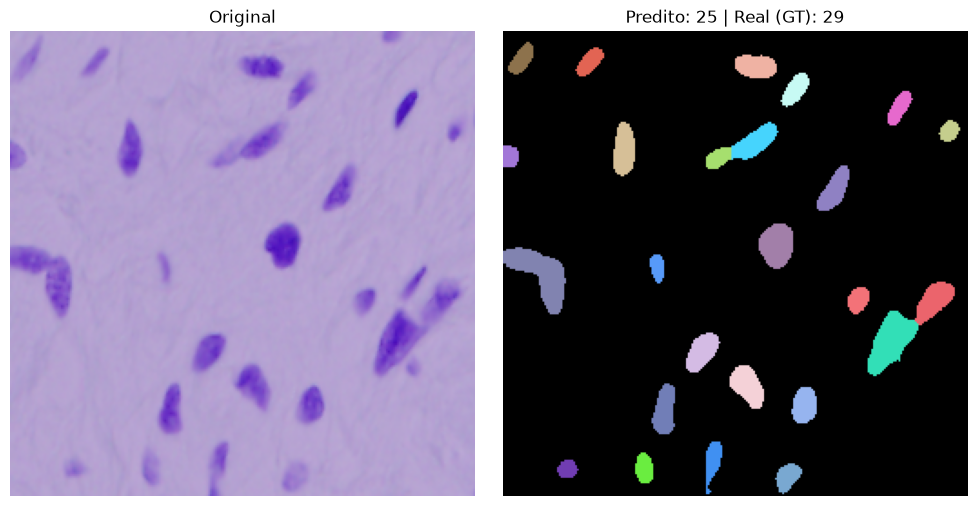

Processando: ../data/stage1_train\0e4c2e2780de7ec4312f0efcd86b07c3738d21df30bb4643659962b4da5505a3\images\0e4c2e2780de7ec4312f0efcd86b07c3738d21df30bb4643659962b4da5505a3.png


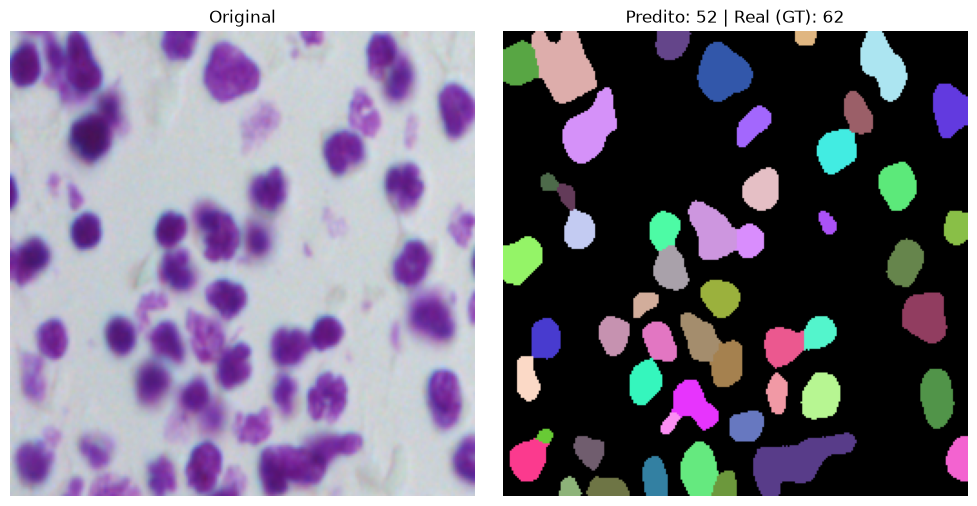

Processando: ../data/stage1_train\0e5edb072788c7b1da8829b02a49ba25668b09f7201cf2b70b111fc3b853d14f\images\0e5edb072788c7b1da8829b02a49ba25668b09f7201cf2b70b111fc3b853d14f.png


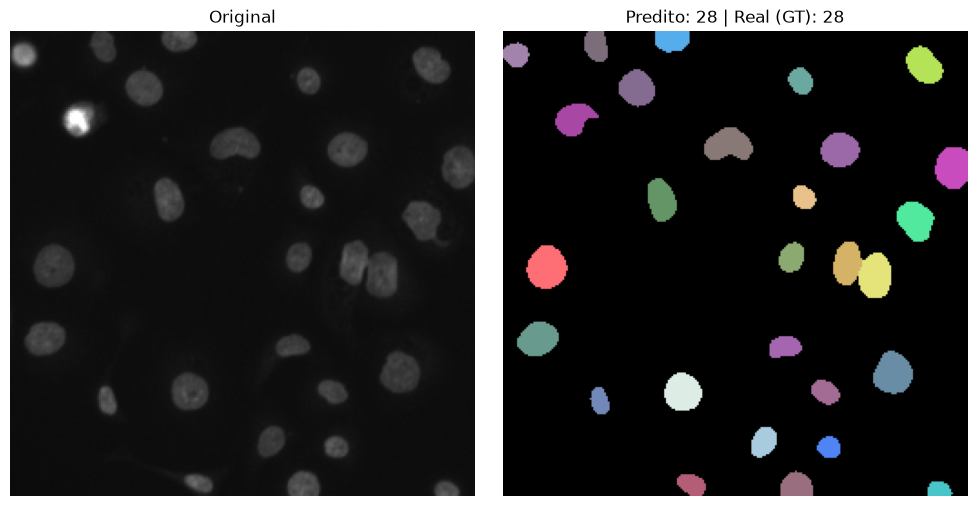

Processando: ../data/stage1_train\0ea221716cf13710214dcd331a61cea48308c3940df1d28cfc7fd817c83714e1\images\0ea221716cf13710214dcd331a61cea48308c3940df1d28cfc7fd817c83714e1.png


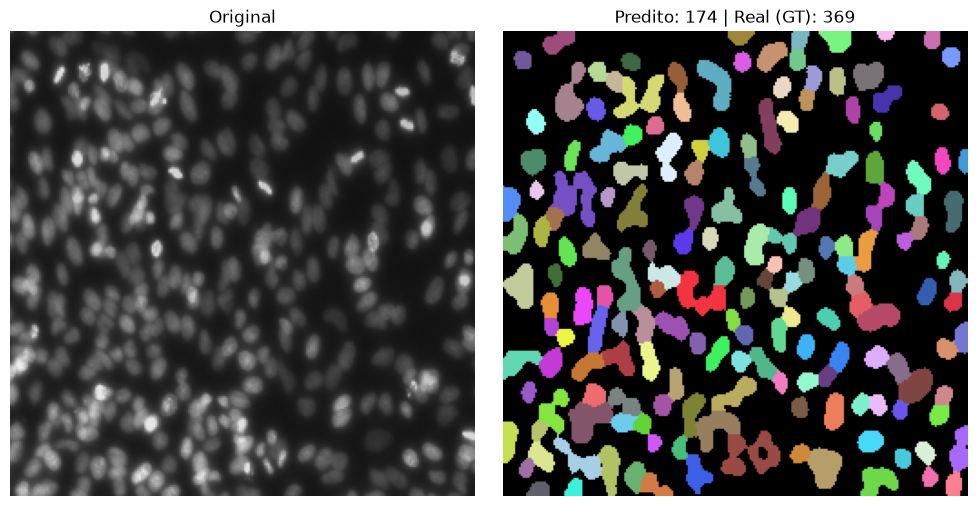

Processando: ../data/stage1_train\1023509cf8d4c155467800f89508690be9513431992f470594281cd37dbd020d\images\1023509cf8d4c155467800f89508690be9513431992f470594281cd37dbd020d.png


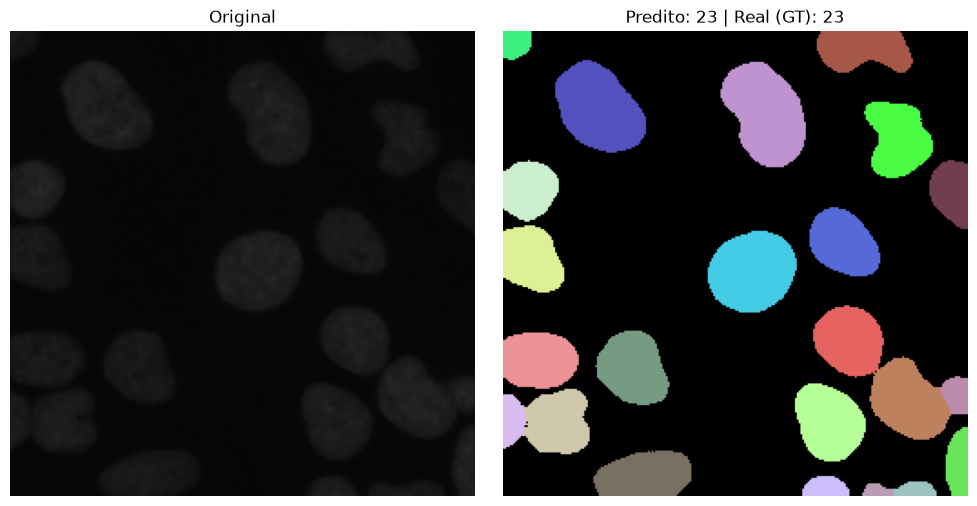

Processando: ../data/stage1_train\10328b822b836e67b547b4144e0b7eb43747c114ce4cacd8b540648892945b00\images\10328b822b836e67b547b4144e0b7eb43747c114ce4cacd8b540648892945b00.png


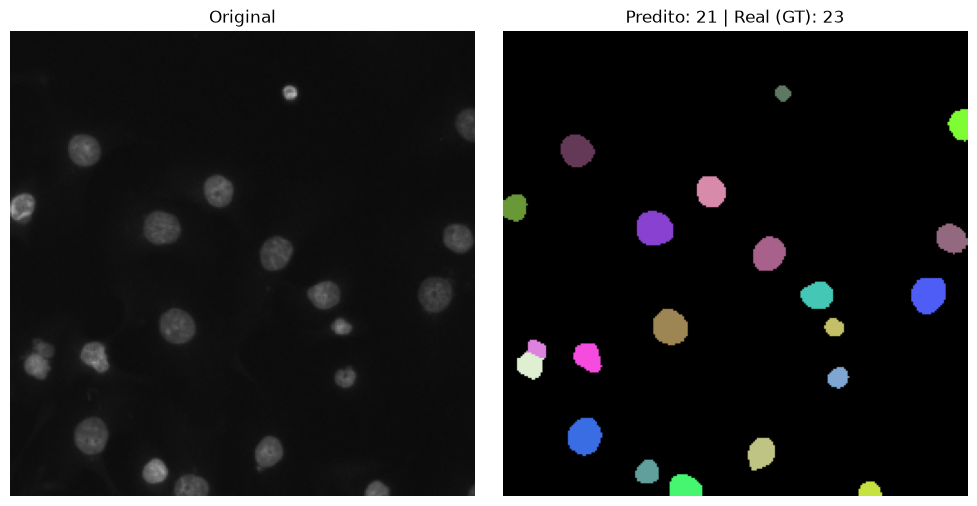

Processando: ../data/stage1_train\10ba6cbee4873b32d5626a118a339832ba2b15d8643f66dddcd7cb2ec80fbc28\images\10ba6cbee4873b32d5626a118a339832ba2b15d8643f66dddcd7cb2ec80fbc28.png


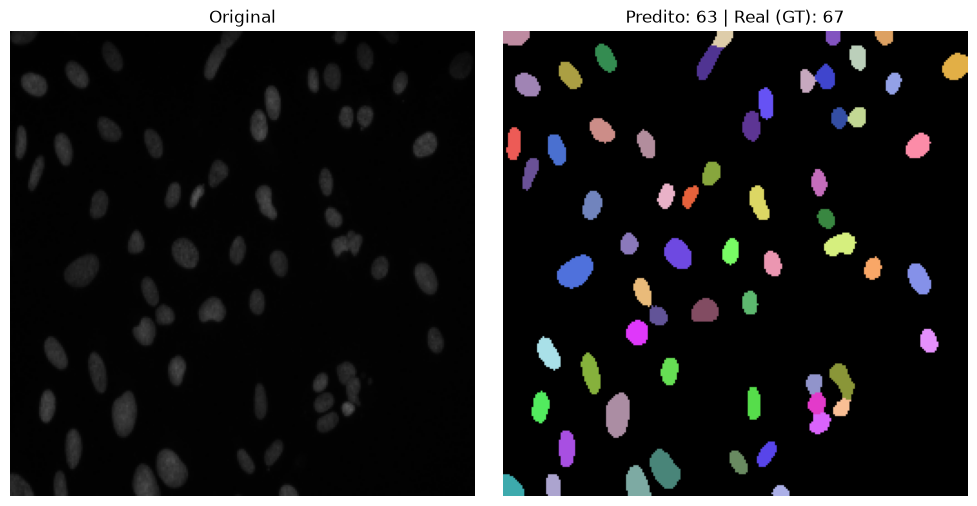

Processando: ../data/stage1_train\11a0170f44e3ab4a8d669ae8ea9546d3a32ebfe6486d9066e5648d30b4e1cb69\images\11a0170f44e3ab4a8d669ae8ea9546d3a32ebfe6486d9066e5648d30b4e1cb69.png


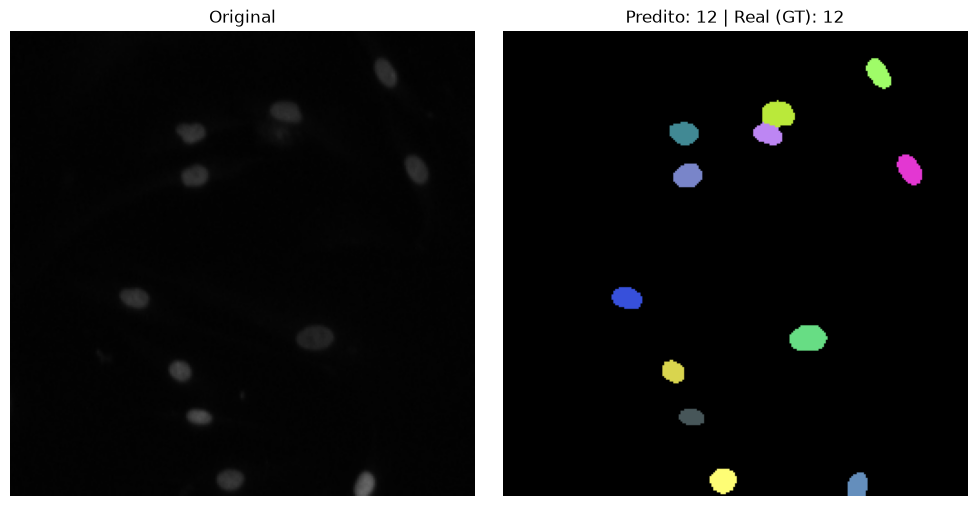

Processando: ../data/stage1_train\12aeefb1b522b283819b12e4cfaf6b13c1264c0aadac3412b4edd2ace304cb40\images\12aeefb1b522b283819b12e4cfaf6b13c1264c0aadac3412b4edd2ace304cb40.png


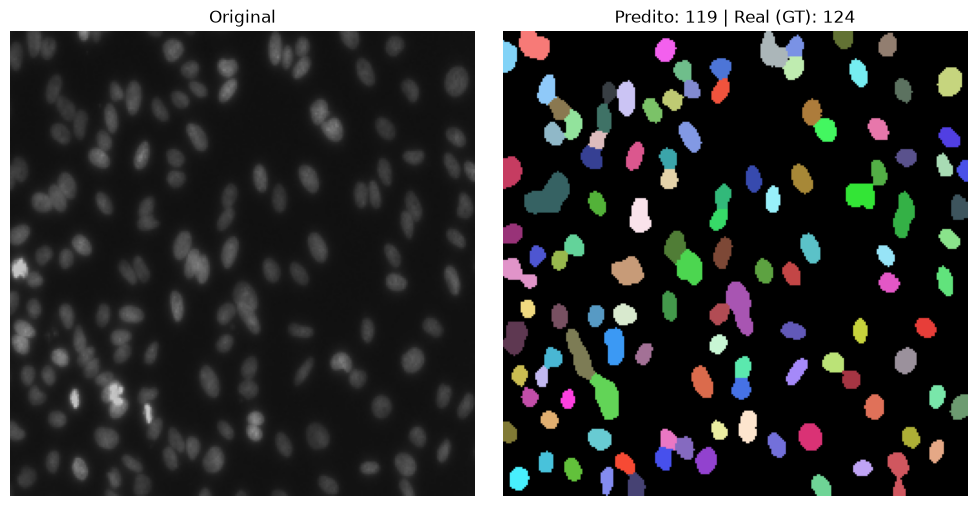

Processando: ../data/stage1_train\12f89395ad5d21491ab9cec137e247652451d283064773507d7dc362243c5b8e\images\12f89395ad5d21491ab9cec137e247652451d283064773507d7dc362243c5b8e.png


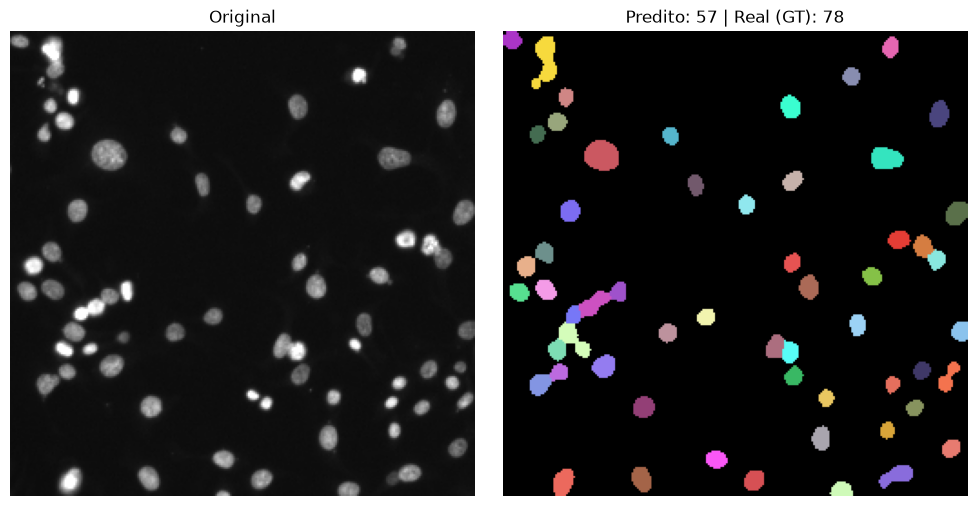

Processando: ../data/stage1_train\136000dc18fa6def2d6c98d4d0b2084d13c22eaffe82e26c665bcaa2a9e51261\images\136000dc18fa6def2d6c98d4d0b2084d13c22eaffe82e26c665bcaa2a9e51261.png


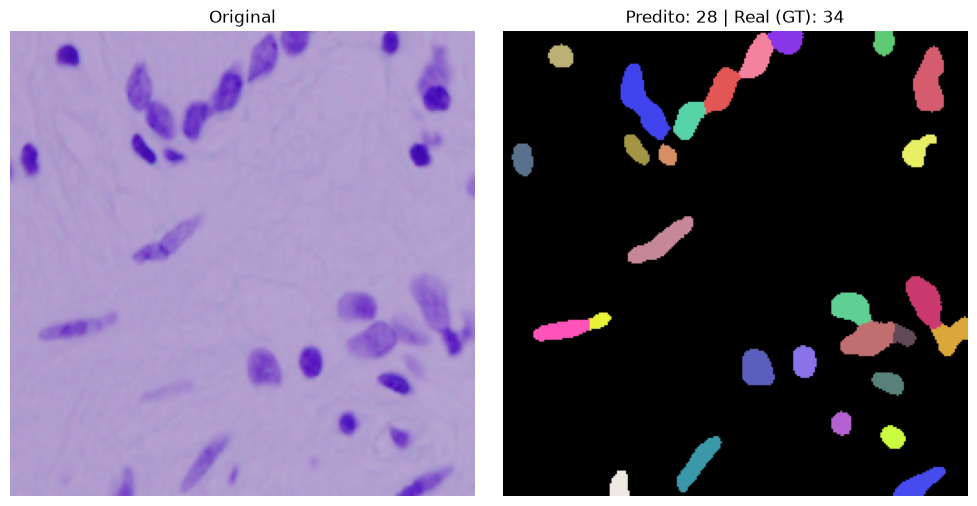

Processando: ../data/stage1_train\139946af9e2c7ef4f0298e622b831dbef5e5c0cd088eb5bc3382f8df9355443d\images\139946af9e2c7ef4f0298e622b831dbef5e5c0cd088eb5bc3382f8df9355443d.png


KeyboardInterrupt: 

In [4]:
import glob
import os

def inferir_todas_as_imagens_com_gt(diretorio_dataset="../data/stage1_train"):
    padrao_busca = os.path.join(diretorio_dataset, "*/images/*.png")
    caminhos_imagens = glob.glob(padrao_busca)
    
    if not caminhos_imagens:
        print(f"Nenhuma imagem encontrada no diretório: {diretorio_dataset}")
        return
    
    print(f"Total de imagens encontradas: {len(caminhos_imagens)}\n")
    resultados = []
    
    for caminho in caminhos_imagens:
        print(f"Processando: {caminho}")
        img = cv.imread(caminho, cv.IMREAD_COLOR)
        
        if img is None:
            print(f"  -> Erro ao ler a imagem.")
            continue
            
        # Descobre o caminho da pasta de máscaras reais (Ground Truth) correspondente
        # Ex: de .../images/hash.png para .../masks/*.png
        pasta_img = os.path.dirname(caminho)
        pasta_base = os.path.dirname(pasta_img)
        pasta_masks = os.path.join(pasta_base, "masks")
        
        # Conta quantas máscaras reais existem para esta imagem
        masks_gt_paths = glob.glob(os.path.join(pasta_masks, "*.png"))
        contagem_real = len(masks_gt_paths)
        
        # Pré-processamento e Inferência
        img_rs = cv.resize(cv.cvtColor(img, cv.COLOR_BGR2RGB), (256, 256))
        img_t = torch.from_numpy(img_rs / 255.0).permute(2,0,1).float().unsqueeze(0).to(DEVICE)
        
        with torch.no_grad():
            cls, dist = model(img_t)
            p = torch.nn.functional.softmax(cls, dim=1)[0].cpu().numpy()
            d = dist.squeeze(1)[0].cpu().numpy()
            
        masks_pred = decode_watershed(p, d, 0.3, 0.5, 2)
        mask_color = np.zeros_like(img_rs)
        for m in masks_pred: 
            mask_color[m > 0] = np.random.randint(50, 255, 3)
            
        contagem_pred = len(masks_pred)
        resultados.append((caminho, contagem_pred, contagem_real))
        
        # Plot comparativo
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        ax[0].imshow(img_rs)
        ax[0].axis('off')
        ax[0].set_title('Original')
        
        ax[1].imshow(mask_color)
        ax[1].axis('off')
        ax[1].set_title(f'Predito: {contagem_pred} | Real (GT): {contagem_real}')
        
        plt.tight_layout()
        plt.show()
        
    return resultados

# Executa para todas as imagens
resultados_gerais = inferir_todas_as_imagens_com_gt()